# STEP15. 하품 구간의 눈 감김 판정 분석

## 분석 질문

- 실제 하품 구간에서 Eye CNN이 프레임을 Closed로 판정하는 비율은 얼마인가.
- 하품 구간의 Closed 판정 비율이 microsleep 영상에서 관찰되는 비율과 어떻게 다른가.
- 눈 감김 지표만으로 하품과 microsleep을 구분할 수 있는지 확인한다.

## STEP14와 다른 점

- STEP14: 원본 영상 단위 비교 → 영상 길이 차이의 영향을 받음
- STEP15: 하품 구간과 microsleep 프레임을 이용한 Closed 판정 비율 비교
- 목적: 하품 상황에서 눈 감김 지표가 어떻게 나타나는지 확인

| | STEP14 | STEP15 |
|---|---|---|
| 입력 | 원본 영상 전체 | 전처리 얼굴 crop |
| 단위 | 영상(길이 교란) | 프레임 비율(교란 없음) |
| 질문 | microsleep vs 하품 영상 판별 | 하품 순간 Closed 오경보율 |

## 입력

| 구분 | 경로 |
|---|---|
| 전처리 얼굴 crop | `config.DATA_DIR / "proceed" / "NITYMED" / "DSM_Dataset-HDTV720" / "processed"` |
| 학습된 Eye CNN + 임계값 | `config.ARTIFACT_DIR / "eye_<tag>.keras"` (STEP12) |
| YuNet 모델 | `config.YUNET_MODEL` |

## 출력

| 파일 | 위치 |
|---|---|
| `frame_pclosed.csv` (프레임별 확률) | `config.OUTPUTS_DIR / "yawn_fp"` |
| `video_closed_rate.csv` (영상별 요약) | `config.OUTPUTS_DIR / "yawn_fp"` |
| `pclosed_dist.png` | `config.OUTPUTS_DIR / "yawn_fp"` |


**PART A — 준비**

1. STEP12에서 선택한 Eye CNN과 threshold **0.93**을 그대로 사용한다.
2. 전처리된 `yawn_only` 얼굴 crop을 사용한다.
3. microsleep은 영상당 최대 **200프레임**을 균등 샘플링한다.

**PART B — 프레임 추론**

1. 각 얼굴 crop에서 P(Closed)를 계산한다.
2. STEP13·14와 동일하게 좌·우 눈 중 높은 Closed 확률을 해당 프레임의 값으로 사용한다.

## PART A — 준비

### 목적

- STEP12 가 고른 모델·임계값을 그대로 가져온다.
- 전처리 얼굴 crop 목록을 만들고 영상당 프레임 수를 맞춘다.

In [1]:
# [셀 1] 설정 · 모델 · 임계값 (import·경로·시드는 여기서 한 번만)

# --- 저장소 루트 부트스트랩 (모든 노트북 공통, 수정 금지) ---
import sys
from pathlib import Path

_anchors = []
if "__vsc_ipynb_file__" in globals():          # VS Code Notebook
    _anchors.append(Path(globals()["__vsc_ipynb_file__"]).resolve().parent)
if globals().get("_dh"):                        # IPython 커널 시작 폴더
    _anchors.append(Path(globals()["_dh"][0]).resolve())
_anchors.append(Path.cwd().resolve())           # 최후 수단

_root = next(
    (p for a in _anchors for p in [a, *a.parents]
     if (p / "config.py").is_file() and (p / "requirements.txt").is_file()),
    None,
)
if _root is not None:
    if str(_root) in sys.path:
        sys.path.remove(str(_root))
    sys.path.insert(0, str(_root))

import config

if _root is not None and Path(config.__file__).resolve().parent != _root:
    raise ImportError(f"의도하지 않은 config.py 가 import 되었습니다: {config.__file__}")
# --- 부트스트랩 끝 ---

_src = str(config.PROJECT_ROOT / "src")
if _src not in sys.path:
    sys.path.insert(0, _src)

import json
import time

import cv2
import numpy as np
import pandas as pd
import tensorflow as tf

import build_dmd_eye_dataset as B
from eye_preprocess import preprocess_eye

MODEL_TAG = "mrl+dmd__eval-dmd__gray128"     # STEP12 에서 고른 C 조건
SIZE, GRAY = 128, True
SEED = 42

OUT_DIR = config.OUTPUTS_DIR / "yawn_fp"
OUT_DIR.mkdir(parents=True, exist_ok=True)

_model_path = config.ARTIFACT_DIR / f"eye_{MODEL_TAG}.keras"
_metrics_path = config.ARTIFACT_DIR / f"eye_{MODEL_TAG}_metrics.json"
for _p in (_model_path, _metrics_path):
    if not _p.exists():
        raise FileNotFoundError(f"{config._rel(_p)} 가 없습니다. STEP12 를 먼저 실행하세요.")

THRESHOLD = float(json.loads(_metrics_path.read_text(encoding="utf-8"))["threshold"])
eye_model = tf.keras.models.load_model(_model_path)
if tuple(eye_model.input_shape[1:]) != (SIZE, SIZE, 1 if GRAY else 3):
    raise ValueError(f"모델 입력 {eye_model.input_shape} 와 SIZE/GRAY 불일치")
detector = B.YuNetDetector()

# 전처리 crop 루트 (data/proceed 아래)
PROC = config.DATA_DIR / "proceed" / "NITYMED" / "DSM_Dataset-HDTV720" / "processed"
if not PROC.is_dir():
    raise FileNotFoundError(f"전처리 폴더가 없습니다: {config._rel(PROC)}")

print("모델   :", config._rel(_model_path))
print("임계값  :", round(THRESHOLD, 4), "(STEP12 val 에서 결정)")
print("전처리 :", config._rel(PROC))

모델   : model\artifacts\eye_mrl+dmd__eval-dmd__gray128.keras
임계값  : 0.93 (STEP12 val 에서 결정)
전처리 : data\proceed\NITYMED\DSM_Dataset-HDTV720\processed


### 결정 박스 16 — 왜 전처리 crop 을 쓰는가

- 문제: STEP14 는 원본 영상을 읽었는데, 여기서는 전처리 얼굴 crop 을 쓴다.
- 선택: **전처리 crop 사용.** 이 STEP 의 질문(하품 순간 오경보율)에는 하품 순간만 잘린 `yawn_only` 가 정확히 맞다.
- 근거: STEP14 에서 전처리 crop 을 영상 비교에 쓰지 못한 이유는 `yawn_only` 가 하품 순간(약 5초)만 남겨 microsleep 전체 영상과 관찰 창이 달랐기 때문이다. 그러나 "하품 순간에 눈이 Closed 로 분류되는 비율"은 프레임 단위 비율이라 관찰 창 길이와 무관하다. 오히려 하품 순간만 있는 편이 정확하다.
- 부수 효과로 원본 1280x720 검출(74ms/frame)을 건너뛰어 훨씬 빠르다.
- 사전 계획.

### 결정 박스 17 — 얼굴 crop 에 YuNet 을 다시 돌리는 이유

- 문제: 입력이 이미 얼굴 crop(232x224)인데 YuNet 을 또 돌린다.
- 선택: **돌린다.** 눈 위치(키포인트)를 얻어 STEP12~14 와 같은 눈 crop 을 뜨기 위해서다.
- 근거: 눈 CNN 은 얼굴이 아니라 눈 crop 을 입력으로 받는다. STEP13·14 와 동일한 파이프라인(얼굴 → YuNet → 눈 crop → CNN)을 유지해야 결과가 비교 가능하다. 사전 점검에서 이 crop 들에 대해 YuNet 검출률 100% 를 확인했다.
- 한계: 전처리 crop 은 STEP14 의 전체 프레임 검출과 crop 경계가 다를 수 있어, 눈 위치가 미세하게 다를 수 있다(한계 절에 기록).
- 사전 계획.

In [2]:
# [셀 2] 프레임 목록 + 영상당 캡
CAP_PER_VIDEO = 200          # 영상당 최대 프레임. microsleep 은 전체가 커서 균등 샘플

def collect(subdir, label):
    """processed/<subdir> 아래 jpg 를 영상별로 모은다. label: yawn=0, microsleep=1."""
    rows = []
    for v_dir in sorted((PROC / subdir).glob("*/*")):    # <gender>/<video>
        if not v_dir.is_dir():
            continue
        jpgs = sorted(v_dir.glob("*.jpg"))
        if len(jpgs) > CAP_PER_VIDEO:                     # 균등 샘플 (시간축 고르게)
            idx = np.linspace(0, len(jpgs) - 1, CAP_PER_VIDEO).round().astype(int)
            jpgs = [jpgs[i] for i in idx]
        for p in jpgs:
            rows.append(dict(path=str(p), video=v_dir.name,
                             gender=v_dir.parent.name, group=label))
    return rows

frames = pd.DataFrame(collect("yawn_only", "yawn") + collect("Microsleep", "microsleep"))
print("프레임 수:")
print(frames.groupby("group").agg(frames=("path", "size"),
                                  videos=("video", "nunique")).to_string())

프레임 수:
            frames  videos
group                     
microsleep    3740      19
yawn         12662     104


## PART B — 프레임 추론

### 목적

- 각 얼굴 crop 에 눈 CNN 을 돌려 Closed 확률을 얻는다.
- STEP13·14 와 같은 max(좌,우) 규칙(한쪽이라도 감기면 Closed)을 쓴다.

In [3]:
# [셀 3] 프레임 추론 함수 + 한 프레임 시범
def pclosed_of_crop(face_crop):
    """얼굴 crop -> Closed 확률. 검출 실패면 NaN."""
    f = detector.detect_face(face_crop)
    if f is None:
        return np.nan
    res = detector.eye_crops(face_crop, f)
    if res is None:
        return np.nan
    crops, _ = res
    batch = np.stack([preprocess_eye(cr, size=SIZE, grayscale=GRAY,
                                     do_sharpen=False, input_is_bgr=True)
                      for _s, cr in crops])
    return float(eye_model(batch, training=False).numpy()[:, 0].max())


_p = frames[frames.group == "yawn"].iloc[0].path
_t0 = time.perf_counter()
_val = pclosed_of_crop(cv2.imread(_p))
print("샘플 하품 프레임:", Path(_p).name)
print(f"P(Closed) = {_val:.4f}  |  1프레임 {(time.perf_counter()-_t0)*1000:.0f} ms")
print(f"전체 {len(frames):,} 프레임 예상 시간 ≈ {len(frames)*(time.perf_counter()-_t0)/60:.0f} 분")

샘플 하품 프레임: P1042778_720_000408.jpg
P(Closed) = 0.9234  |  1프레임 185 ms
전체 16,402 프레임 예상 시간 ≈ 51 분


In [4]:
# [셀 4] 전체 프레임 P(Closed) 계산  ※ 실행 시간이 긴 셀
FRAME_CSV = OUT_DIR / "frame_pclosed.csv"

if FRAME_CSV.exists():
    fr = pd.read_csv(FRAME_CSV)                    # 이미 계산했으면 재사용
    print("저장된 결과 재사용:", config._rel(FRAME_CSV), f"({len(fr):,} rows)")
else:
    probs = []
    t_start = time.perf_counter()
    for n, r in enumerate(frames.itertuples(), 1):
        img = cv2.imread(r.path)
        probs.append(pclosed_of_crop(img) if img is not None else np.nan)
        if n % 2000 == 0:
            print(f"  {n:6d}/{len(frames)}  ({time.perf_counter()-t_start:.0f}s)")
    fr = frames.assign(p_closed=probs)
    fr.to_csv(FRAME_CSV, index=False)
    print(f"\n총 {time.perf_counter()-t_start:.0f}s | 저장: {config._rel(FRAME_CSV)}")

fr["detected"] = fr.p_closed.notna()
fr["closed"] = fr.detected & (fr.p_closed >= THRESHOLD)
print("\n검출 성공률:", round(fr.detected.mean(), 4))
print(fr.groupby("group").agg(frames=("path", "size"),
                              detect_rate=("detected", "mean")).round(4).to_string())

    2000/16402  (56s)
    4000/16402  (109s)
    6000/16402  (162s)
    8000/16402  (218s)
   10000/16402  (269s)
   12000/16402  (319s)
   14000/16402  (370s)
   16000/16402  (424s)

총 435s | 저장: outputs\yawn_fp\frame_pclosed.csv

검출 성공률: 0.9973
            frames  detect_rate
group                          
microsleep    3740       0.9987
yawn         12662       0.9969


## PART C — 오경보 분석

### 목적

- 하품 프레임의 Closed 오경보율을 프레임·영상 단위로 잰다.
- 그 비율이 microsleep 영상의 Closed 비율(PERCLOS)과 겹치는지 본다.

In [5]:
# [셀 5] 하품 오경보율 + microsleep Closed 비율 (프레임·영상 단위)
det = fr[fr.detected].copy()          # 검출 성공 프레임만

# 프레임 단위 Closed 비율
print("=== 프레임 단위 Closed 비율 (임계 {:.2f}) ===".format(THRESHOLD))
print(det.groupby("group").closed.agg(["mean", "size"]).round(4).to_string())

# 영상 단위: 영상마다 Closed 프레임 비율 -> 그 분포
vid = (det.groupby(["group", "video"])
          .agg(closed_rate=("closed", "mean"),
               mean_p=("p_closed", "mean"),
               n=("closed", "size"))
          .reset_index())
vid.to_csv(OUT_DIR / "video_closed_rate.csv", index=False)

print("\n=== 영상 단위 Closed 비율 분포 ===")
print(vid.groupby("group").closed_rate
        .agg(["median", "mean", "std", "min", "max"]).round(4).to_string())
print("\n저장:", config._rel(OUT_DIR / "video_closed_rate.csv"))

=== 프레임 단위 Closed 비율 (임계 0.93) ===
              mean   size
group                    
microsleep  0.1992   3735
yawn        0.2573  12623

=== 영상 단위 Closed 비율 분포 ===
            median    mean     std     min     max
group                                             
microsleep  0.1500  0.1965  0.1653  0.0201  0.6150
yawn        0.1886  0.2506  0.2167  0.0000  0.8815

저장: outputs\yawn_fp\video_closed_rate.csv


### 관찰 결과

- 하품 프레임의 Closed 판정 비율은 **0.2573**(12,623프레임)이다.
- microsleep 영상에서 샘플링한 프레임의 Closed 판정 비율은 **0.1992**(3,735프레임)이다.
- 영상 단위 Closed 비율 중앙값은 하품 **0.189**, microsleep **0.150**이었다.
- 영상 단위 Closed 비율의 범위는 하품 **[0.00, 0.88]**, microsleep **[0.02, 0.62]**로 상당 부분 겹쳤다.
- 얼굴 검출 성공률은 하품 **0.9969**, microsleep **0.9987**로 높았다.

In [6]:
# [셀 6] 겹침 정량화 — 눈 지표로 하품과 microsleep 영상이 구분되는가
def auc_ci(y, s):
    """Mann-Whitney AUC + Hanley-McNeil 95% CI."""
    y = np.asarray(y, float); s = np.asarray(s, float)
    order = np.argsort(s, kind="mergesort")
    rank = np.empty(len(s)); rank[order] = np.arange(1, len(s) + 1)
    ss = s[order]; i = 0
    while i < len(s):
        j = i
        while j + 1 < len(s) and ss[j + 1] == ss[i]:
            j += 1
        if j > i:
            rank[order[i:j + 1]] = rank[order[i:j + 1]].mean()
        i = j + 1
    n1, n2 = y.sum(), (1 - y).sum()
    a = (rank[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n2)
    q1, q2 = a / (2 - a), 2 * a * a / (1 + a)
    se = np.sqrt((a * (1 - a) + (n1 - 1) * (q1 - a * a)
                  + (n2 - 1) * (q2 - a * a)) / (n1 * n2))
    return a, max(0.0, a - 1.96 * se), min(1.0, a + 1.96 * se)

# 영상 단위 Closed 비율로 microsleep(1) vs 하품(0) 을 가를 수 있는가 (길이 교란 없음)
y = (vid.group == "microsleep").astype(int).values
a, lo, hi = auc_ci(y, vid.closed_rate.values)
print(f"영상 단위 Closed 비율의 AUC (microsleep vs 하품) : {a:.3f}  [{lo:.3f}, {hi:.3f}]")
print("  0.5 에 가까울수록 눈 지표로 둘을 구분할 수 없다는 뜻.")

# 겹침: 하품 영상 중 microsleep 중앙값 이상인 비율
mic_med = vid[vid.group == "microsleep"].closed_rate.median()
yaw_over = (vid[vid.group == "yawn"].closed_rate >= mic_med).mean()
print(f"\nmicrosleep 영상 Closed 비율 중앙값 : {mic_med:.4f}")
print(f"그 값 이상인 하품 영상 비율        : {yaw_over:.4f}  (높을수록 하품이 졸음처럼 보임)")

영상 단위 Closed 비율의 AUC (microsleep vs 하품) : 0.440  [0.304, 0.577]
  0.5 에 가까울수록 눈 지표로 둘을 구분할 수 없다는 뜻.

microsleep 영상 Closed 비율 중앙값 : 0.1500
그 값 이상인 하품 영상 비율        : 0.5865  (높을수록 하품이 졸음처럼 보임)


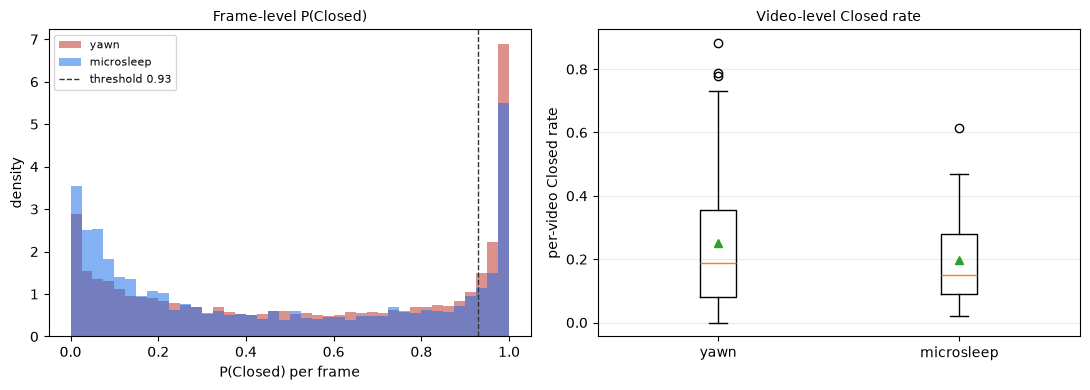

저장: outputs\yawn_fp\pclosed_dist.png


In [9]:
# [셀 7] P(Closed) 분포 그림
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# (좌) 프레임 단위 P(Closed) 히스토그램
for g, col in [("yawn", "#c0392b"), ("microsleep", "#1f6feb")]:
    axes[0].hist(det[det.group == g].p_closed, bins=40, alpha=0.55,
                 density=True, label=g, color=col)
axes[0].axvline(THRESHOLD, ls="--", color="#333", lw=1, label=f"threshold {THRESHOLD:.2f}")
axes[0].set_xlabel("P(Closed) per frame"); axes[0].set_ylabel("density")
axes[0].set_title("Frame-level P(Closed)", fontsize=10)
axes[0].legend(fontsize=8)

# (우) 영상 단위 Closed 비율 박스플롯

yawn_rate = pd.to_numeric(
    vid.loc[vid["group"] == "yawn", "closed_rate"],
    errors="coerce"
).dropna().to_numpy(dtype=float)

microsleep_rate = pd.to_numeric(
    vid.loc[vid["group"] == "microsleep", "closed_rate"],
    errors="coerce"
).dropna().to_numpy(dtype=float)

data = [yawn_rate, microsleep_rate]

axes[1].boxplot(
    data,
    tick_labels=["yawn", "microsleep"],
    showmeans=True
)

axes[1].set_ylabel("per-video Closed rate")
axes[1].set_title("Video-level Closed rate", fontsize=10)
axes[1].grid(alpha=0.25, axis="y")

plt.tight_layout()
plt.savefig(OUT_DIR / "pclosed_dist.png", dpi=130)
plt.show()
print("저장:", config._rel(OUT_DIR / "pclosed_dist.png"))

### 관찰 결과

- 하품 프레임의 Closed 판정 비율은 **0.2573**(12,623프레임 중)이다.
- microsleep 영상에서 균등 샘플링한 프레임의 Closed 판정 비율은 **0.1992**(3,735프레임 중)로, 하품 프레임보다 낮았다.
- 영상 단위 Closed 비율 중앙값은 하품 **0.189**, microsleep **0.150**이며, 범위는 하품 [0.00, 0.88], microsleep [0.02, 0.62]로 상당 부분 겹친다.
- 얼굴 검출 성공률은 두 그룹 모두 **0.997**로 높아, 검출 실패가 결과에 큰 영향을 준 것으로 보이지 않는다.


## 해석

- 하품 구간에서도 Closed 판정이 상당 비율 나타났으며, 하품 프레임의 비율은 microsleep 영상에서 관찰된 비율보다 높았다.
- 영상 단위 Closed 비율의 AUC는 **0.440 [0.304, 0.577]**로, 95% 신뢰구간이 0.5를 포함했다.
- 따라서 이 표본에서는 **Closed 비율만으로 하품과 microsleep을 유의하게 구분하는 판별력을 확인하지 못했다.**
- 이는 Eye CNN의 눈 감김 검출 성능 자체가 낮다는 의미가 아니라, **눈 감김이라는 단일 신호만으로 두 상황을 구분하는 데 한계가 있을 가능성**을 보여준다.
- STEP14에서도 길이 영향을 고려한 후 눈 지표의 판별력이 명확하지 않았다는 점에서, 두 분석에서 같은 방향의 결과가 관찰되었다.

## 한계

- `yawn_only`는 하품 순간을 중심으로 잘린 데이터이므로, 전체 하품 영상의 특성을 대표한다고 볼 수 없다.
- microsleep은 영상 단위 라벨이므로, **19.9%는 순수 microsleep 순간의 Closed 비율이 아니라 샘플링된 microsleep 영상 프레임의 비율**이다.
- microsleep은 영상당 최대 200프레임을 균등 샘플링했으므로 전체 프레임을 사용한 결과는 아니다.
- threshold **0.93**은 DMD validation에서 결정된 값이며 NITYMED에서 최적화하지 않았다.
- microsleep 영상이 19개로 적어 영상 단위 AUC의 신뢰구간이 넓다.
- 전처리 얼굴 crop에 다시 YuNet을 적용했으므로 STEP13·14와 crop 조건에 차이가 있을 가능성이 있다.

## STEP15 요약

### Takeaway

- 하품 구간의 **25.7%**가 Closed로 판정되었으며, microsleep 영상에서 샘플링한 프레임은 **19.9%**였다.
- 영상 단위 Closed 비율 AUC는 **0.440 [0.304, 0.577]**로, 이 표본에서는 유의한 판별력을 확인하지 못했다.
- 따라서 **눈 감김 단독으로 하품과 microsleep을 안정적으로 구분하기 어려울 가능성**이 확인되었다.
- 이는 STEP14의 길이 영향을 고려한 분석과 **같은 방향의 결과**다.
- 본 결과는 하품 검출 성능을 평가한 것이 아니라, **하품 상황에서 눈 감김 지표가 어떻게 나타나는지를 확인한 분석**이다.